# Liquidh2o: Predictive Control of Water Tank Levels, part 2 
#### Phase 2 — Time-Aware Modeling, Feature Engineering, Predicting with real data

In this **second phase**, the focus shifts from exploratory modeling to a structured, time-aware prediction pipeline.
The objective is to replace simple tabular models with one that explicitly captures temporal dependencies in each tank’s 30-minute water-level series.

**Key goals**

1. Engineer lag, rolling, and seasonal features to model refill and consumption patterns.

2. Remove variables with no predictive power or that risk target leakage (e.g., weather and slope).

3. Train a robust baseline model (ExtraTreesRegressor) using chronological splits to respect time order.

4. Evaluate forecasting accuracy before moving to LightGBM in the next phase.

---

*Note: All client data is confidential; only synthetic or anonymized samples are shown here.*

#### Scope & Data

Phase 2 uses the same 13 tanks and 30-minute measurements from Phase 1 to ensure comparability.
However, the focus now is on feature engineering and temporal modeling rather than data exploration.


In [14]:
import numpy as np
import pandas as pd
import os
from sqlalchemy import create_engine
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GroupShuffleSplit


## Functions

In [12]:
#0) Small helpers (time + pretty prints)

def _ensure_ts(df, ts_col="updated_at", make_date=True):
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    if make_date and "date" not in df.columns:
        df["date"] = df[ts_col].dt.floor("D")
    return df

def _pp_metrics(title, m, ts=None):
    print(f"\n{title}")
    if ts:
        print(f"  window: {ts[0]}  →  {ts[1]}")
    for k in ["MAE","MSE","RMSE","R2","RMSLE","sMAPE"]:
        if k in m:
            print(f"  {k:6s}: {m[k]:.4f}")
# We are use this functions for quick tests

def run_experiment_2(
    df,
    target="median_level",
    drop_groups=(),
    drop_cols=(),
    test_size=0.20,
    group_by_tank=False,
    random_state=42,
    n_estimators=200,
    lags=(1, 2),              
    rolling_windows=(3,),     
):
    df = df.copy()
    df.columns = df.columns.map(str)

    # --- Create lag & rolling features ---
    if "tank_id" in df.columns and target in df.columns:
        df = df.sort_values(["tank_id", "date"])  # ensure order
        for lag in lags:
            df[f"{target}_lag{lag}"] = df.groupby("tank_id")[target].shift(lag)
        for win in rolling_windows:
            df[f"{target}_rollmean{win}"] = (
                df.groupby("tank_id")[target]
                  .shift(1)  # shift so it doesn't peek at current row
                  .rolling(win)
                  .mean()
            )

    # --- Drop rows with NaN after lag/rolling creation ---
    df = df.dropna(subset=[c for c in df.columns if "lag" in c or "rollmean" in c])

    # --- Drop unwanted groups ---
    groups = {
        "tank_props": ["capacity","max_level"],
        "geo": ["latitude","longitude"],
        "weather": ["tank_temp","tank_precip","tank_humidity","dam_temp","dam_precip","dam_humidity"],
        "time": ["hour","minute","day_of_week","week_end","week","month","year","early_morning","morning","afternoon","night",
        "holiday"],
        "ids": ["tank_id","version_controller","water_network","dam_id","supplies"],
        "slope":["slope_30"]
    }
    to_drop = []
    for g in drop_groups:
        to_drop += [c for c in groups.get(g, []) if c in df.columns]
    to_drop += [c for c in groups["ids"] if c in df.columns]
    to_drop += [c for c in drop_cols if c in df.columns]

    X = df.drop(columns=[target] + to_drop, errors="ignore")
    y = df[target]

    # --- Split ---
    if group_by_tank and "tank_id" in df.columns:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        train_idx, test_idx = next(gss.split(X, y, groups=df["tank_id"].astype(str)))
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, shuffle=True
        )

    # --- Preprocessing ---
    numeric_tf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_tf = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocess = ColumnTransformer(
        transformers=[
            ('num', numeric_tf, selector(dtype_include=np.number)),
            ('cat', categorical_tf, selector(dtype_exclude=np.number)),
        ],
        remainder='drop'
    )

    # --- Model ---
    et = ExtraTreesRegressor(
        n_estimators=n_estimators,
        max_depth=20,
        max_features='sqrt',
        random_state=random_state,
        n_jobs=-1
    )

    pipe = Pipeline([('prep', preprocess), ('model', et)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    # --- Metrics ---
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)

    try:
        rmse = mean_squared_error(y_test, pred, squared=False)  # newer sklearn
    except TypeError:
        rmse = np.sqrt(mse)  
    
    r2 = r2_score(y_test, pred)
    eps = 1e-9
    mape = np.mean(np.abs((y_test - pred) / np.maximum(np.abs(y_test), eps)))
    rmsle = np.sqrt(np.mean((np.log1p(np.maximum(pred, 0)) - np.log1p(np.maximum(y_test, 0))) ** 2))

    metrics = dict(MAE=mae, MSE=mse, RMSE=rmse, R2=r2, MAPE=mape, RMSLE=rmsle)
    return metrics, pipe, X_train.columns.tolist()

#1) Time features (uses updated_at)

def _make_time_features(
    df, target="median_level", lags=(), roll_windows=(), seasonal_lags=(),
    by=["tank_id"], ts_col="updated_at"
):
    df = _ensure_ts(df, ts_col)
    df = df.sort_values(by + [ts_col])

    for L in lags:
        df[f"{target}_lag{L}"]  = df.groupby(by)[target].shift(L)
    for L in seasonal_lags:
        df[f"{target}_slag{L}"] = df.groupby(by)[target].shift(L)
    for W in roll_windows:
        g = df.groupby(by)[target].shift(1)
        df[f"{target}_rollmean{W}"] = g.rolling(W, min_periods=max(2, W//2)).mean()
        df[f"{target}_rollstd{W}"]  = g.rolling(W, min_periods=max(2, W//2)).std()

    eng_cols = [c for c in df.columns if c.startswith(f"{target}_lag")
                or c.startswith(f"{target}_slag") or "rollmean" in c or "rollstd" in c]
    if eng_cols:
        df = df.dropna(subset=eng_cols)
    return df
#2) Train + evaluate (prints metrics, split info)

def _smape(y_true, y_pred, eps=1e-9):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return float(np.mean(np.abs(y_true - y_pred) / np.maximum(denom, eps)))

def _build_groups_dict():
    return {
        "tank_props": ["capacity","max_level"],
        "geo": ["latitude","longitude"],
        "weather": ["tank_temp","tank_precip","tank_humidity","dam_temp","dam_precip","dam_humidity"],
        "time": ["hour","minute","day_of_week","week_end","week","month","year",
                 "early_morning","morning","afternoon","night","holiday"],
        "ids": ["tank_id","version_controller","water_network","dam_id","supplies"],
        "leakage": ["slope_30"],
    }

def run_experiment_timeaware(
    df, target="median_level", ts_col="updated_at",
    cutoff_frac=0.8, cutoff_date=None,
    drop_groups=("weather","leakage"), drop_cols=(),
    lags=(1,2,3,6,12), roll_windows=(3,6,12,24), seasonal_lags=(48,96,336),
    model_type="extratrees", n_estimators=400, random_state=42, log_target=True,
    verbose=True
):
    df = df.copy()
    df.columns = df.columns.map(str)
    df = _make_time_features(df, target, lags, roll_windows, seasonal_lags, ["tank_id"], ts_col)

    groups = _build_groups_dict()
    to_drop = []
    for g in drop_groups: to_drop += [c for c in groups.get(g, []) if c in df.columns]
    to_drop += [c for c in groups["ids"] if c in df.columns]
    to_drop += [c for c in drop_cols if c in df.columns]

    df = _ensure_ts(df, ts_col)
    df = df.sort_values(["tank_id", ts_col])

    if cutoff_date is None:
        cutoff_idx = int(len(df) * cutoff_frac)
        cutoff_val = df[ts_col].iloc[cutoff_idx]
    else:
        cutoff_val = pd.to_datetime(cutoff_date)

    train_df = df[df[ts_col] <= cutoff_val]
    test_df  = df[df[ts_col] >  cutoff_val]
    if len(train_df) == 0 or len(test_df) == 0:
        raise ValueError("Train/test split is empty — adjust cutoff.")

    X_train = train_df.drop(columns=[target] + to_drop, errors="ignore")
    y_train = train_df[target]
    X_test  = test_df.drop(columns=[target] + to_drop, errors="ignore")
    y_test  = test_df[target]

    X_train.columns = X_train.columns.map(str)
    X_test.columns  = X_test.columns.map(str)
    X_train = X_train.loc[:, ~X_train.columns.duplicated()].copy()
    X_test  = X_test.loc[:,  ~X_test.columns.duplicated()].copy()

    numeric_tf = Pipeline([('imputer', SimpleImputer(strategy='median')),
                           ('scaler', StandardScaler())])
    categorical_tf = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                               ('ohe', OneHotEncoder(handle_unknown='ignore'))])
    preprocess = ColumnTransformer(
        transformers=[('num', numeric_tf, selector(dtype_include=np.number)),
                      ('cat', categorical_tf, selector(dtype_exclude=np.number))],
        remainder='drop'
    )

    def _log1p(y): return np.log1p(np.maximum(y, 0))
    def _exp1m(y): return np.expm1(y)

    base_model = (GradientBoostingRegressor(random_state=random_state)
                  if model_type=="gbrt"
                  else ExtraTreesRegressor(n_estimators=n_estimators, max_depth=None,
                                           max_features="sqrt", random_state=random_state, n_jobs=-1))

    if log_target:
        y_train_fit = _log1p(y_train.values.reshape(-1,1)).ravel()
        pipe = Pipeline([('prep', preprocess), ('model', base_model)])
        pipe.fit(X_train, y_train_fit)
        y_pred_test = _exp1m(pipe.predict(X_test))
    else:
        pipe = Pipeline([('prep', preprocess), ('model', base_model)])
        pipe.fit(X_train, y_train)
        y_pred_test = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred_test)
    mse  = mean_squared_error(y_test, y_pred_test)
    rmse = mean_squared_error(y_test, y_pred_test, squared=False)
    r2   = r2_score(y_test, y_pred_test)
    rmsle = np.sqrt(np.mean((np.log1p(np.maximum(y_pred_test,0)) - np.log1p(np.maximum(y_test,0)))**2))
    smape = _smape(y_test.values, y_pred_test)
    metrics = dict(MAE=mae, MSE=mse, RMSE=rmse, R2=r2, RMSLE=rmsle, sMAPE=smape)

    if verbose:
        print(f"\n Train/Test using ts={ts_col}")
        print(f"  rows: train={len(train_df):,}  test={len(test_df):,}")
        _pp_metrics(" Evaluation Metrics (Holdout)", metrics,
                    ts=(train_df[ts_col].min(), test_df[ts_col].max()))

    return metrics, pipe, X_train.columns.tolist(), cutoff_val

#3) Fit on all data (prints shape + time span)

def fit_full_timeaware(
    df, target="median_level", ts_col="updated_at",
    drop_groups=("weather","leakage"), drop_cols=(),
    lags=(1,2,3,6,12), roll_windows=(3,6,12,24), seasonal_lags=(48,96,336),
    model_type="extratrees", n_estimators=600, random_state=42, log_target=True,
    verbose=True
):
    df = _make_time_features(df.copy(), target, lags, roll_windows, seasonal_lags, ["tank_id"], ts_col)

    groups = _build_groups_dict()
    to_drop = []
    for g in drop_groups: to_drop += [c for c in groups.get(g, []) if c in df.columns]
    to_drop += [c for c in groups["ids"] if c in df.columns]
    to_drop += [c for c in drop_cols if c in df.columns]

    X = df.drop(columns=[target] + to_drop, errors="ignore")
    y = df[target]
    X.columns = X.columns.map(str)
    X = X.loc[:, ~X.columns.duplicated()].copy()

    numeric_tf = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    categorical_tf = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                               ('ohe', OneHotEncoder(handle_unknown='ignore'))])
    preprocess = ColumnTransformer(
        transformers=[('num', numeric_tf, selector(dtype_include=np.number)),
                      ('cat', categorical_tf, selector(dtype_exclude=np.number))],
        remainder='drop'
    )

    base_model = (GradientBoostingRegressor(random_state=random_state)
                  if model_type=="gbrt"
                  else ExtraTreesRegressor(n_estimators=n_estimators, max_depth=None,
                                           max_features="sqrt", random_state=random_state, n_jobs=-1))

    def _log1p(y): return np.log1p(np.maximum(y, 0))
    pipe = Pipeline([('prep', preprocess), ('model', base_model)])
    pipe.fit(X, _log1p(y.values) if log_target else y)

    if verbose:
        ts = _ensure_ts(df, ts_col)[ts_col]
        print("\n🏭 Fitted production model")
        print(f"  rows={len(df):,}  features={X.shape[1]:,}")
        print(f"  time span: {ts.min()}  →  {ts.max()}")

    return pipe, X.columns.tolist()

#4) Predict future (prints sample + horizon)
def predict_future_timeaware(
    pipe, df_past, df_future, used_feats, target="median_level", ts_col="updated_at",
    by=["tank_id"], drop_groups=("weather","leakage"), drop_cols=(),
    lags=(1,2,3,6,12), roll_windows=(3,6,12,24), seasonal_lags=(48,96,336),
    log_target=True, cutoff_val=None, verbose=True
):
    all_df = pd.concat([df_past.copy(), df_future.copy()], ignore_index=True)
    all_df = _ensure_ts(all_df, ts_col)
    all_df = all_df.sort_values(by + [ts_col])

    for L in lags:           all_df[f"{target}_lag{L}"]  = all_df.groupby(by)[target].shift(L)
    for L in seasonal_lags:  all_df[f"{target}_slag{L}"] = all_df.groupby(by)[target].shift(L)
    for W in roll_windows:
        g = all_df.groupby(by)[target].shift(1)
        all_df[f"{target}_rollmean{W}"] = g.rolling(W, min_periods=max(2,W//2)).mean()
        all_df[f"{target}_rollstd{W}"]  = g.rolling(W, min_periods=max(2,W//2)).std()

    if cutoff_val is None:
        cutoff_val = _ensure_ts(df_past, ts_col)[ts_col].max()
    fut_df = all_df[all_df[ts_col] > cutoff_val].copy()

    groups = _build_groups_dict()
    to_drop = []
    for g in drop_groups: to_drop += [c for c in groups.get(g, []) if c in fut_df.columns]
    to_drop += [c for c in groups["ids"] if c in fut_df.columns]
    to_drop += [c for c in drop_cols if c in fut_df.columns]
    if target in fut_df.columns: to_drop.append(target)

    X_future = fut_df.drop(columns=to_drop, errors="ignore")
    X_future.columns = X_future.columns.map(str)
    X_future = X_future.loc[:, ~X_future.columns.duplicated()].copy()

    missing = [c for c in used_feats if c not in X_future.columns]
    if missing: raise ValueError(f"Future frame is missing required features: {missing[:10]} ...")
    X_future = X_future[used_feats]

    preds = pipe.predict(X_future)
    if log_target: preds = np.expm1(preds)
    fut_df["predicted_median_level"] = preds

    if verbose:
        print("\n🔮 Sample Predictions (Future):")
        print(fut_df[["tank_id", ts_col, "predicted_median_level"]].head(10))
        print(f"  horizon: {fut_df[ts_col].min()}  →  {fut_df[ts_col].max()}  | rows={len(fut_df):,}")

    return fut_df


# 5) Compare predicted vs. real (uses same updated_at)

def compare_preds(
    df_actual, df_pred, ts_col="updated_at", start=None, end=None, tanks=None, verbose=True
):
    A = _ensure_ts(df_actual, ts_col)
    P = _ensure_ts(df_pred,   ts_col)
    if start is not None: A = A[A[ts_col] >= pd.to_datetime(start)]; P = P[P[ts_col] >= pd.to_datetime(start)]
    if end   is not None: A = A[A[ts_col] <= pd.to_datetime(end)];   P = P[P[ts_col] <= pd.to_datetime(end)]
    if tanks is not None: A = A[A["tank_id"].isin(tanks)];           P = P[P["tank_id"].isin(tanks)]

    A = A[["tank_id", ts_col, "median_level"]]
    P = P[["tank_id", ts_col, "predicted_median_level"]]

    comp = A.merge(P, on=["tank_id", ts_col], how="inner")

    comp["error"]     = comp["predicted_median_level"] - comp["median_level"]
    comp["abs_error"] = comp["error"].abs()
    denom = (comp["median_level"].abs() + comp["predicted_median_level"].abs())/2.0
    comp["sMAPE"] = comp["abs_error"] / np.where(denom>1e-9, denom, np.nan)
    comp = comp.sort_values(["tank_id", ts_col])

    if verbose:
        print("\n📊 Predictions vs Real (head):")
        print(comp[["tank_id", ts_col, "median_level", "predicted_median_level", "error", "sMAPE"]].head(10))
        print("\n📈 Aggregated Error Metrics:")
        print("  MAE  =", comp["abs_error"].mean())
        print("  RMSE =", np.sqrt((comp["error"]**2).mean()))
        print("  sMAPE=", comp["sMAPE"].mean())
        print(f"  matched rows: {len(comp):,}")

    return comp


## Loading data

In [3]:
# Building the connection URL for df_past . Conection info
pg_user     = os.getenv("pg_user", "postgres")
pg_password = os.getenv("pg_pasword", "3rb414350638")
pg_host     = os.getenv("pg.host", "localhost")
pg_port     = os.getenv("pg_port", "5432")
pg_dbname   = os.getenv("pg_dbname", "liquido")

engine = create_engine(
    f"postgresql+psycopg2://{pg_user}:{pg_password}@{pg_host}:{pg_port}/{pg_dbname}")

In [4]:
df_past = pd.read_sql_table(
    "view_measurements_ml",
    con=engine,
    parse_dates=['updated_at'
                 ]
)

In [5]:
# Building the connection URL for df_future . Conection info
pg_user     = os.getenv("pg_user", "postgres")
pg_password = os.getenv("pg_pasword", "3rb414350638")
pg_host     = os.getenv("pg.host", "localhost")
pg_port     = os.getenv("pg_port", "5432")
pg_dbname   = os.getenv("pg_dbname", "liquido20250728")

engine = create_engine(
    f"postgresql+psycopg2://{pg_user}:{pg_password}@{pg_host}:{pg_port}/{pg_dbname}")

In [6]:
# The present data the one which I used to train the model
df= pd.read_sql_table(
    "view_measurements_ml",
    con=engine,
    parse_dates=['updated_at'
                 ]
)

In [7]:
# The future data, the model havent see it yet. We are going to use it later to predict

df['updated_at'] = pd.to_datetime(df['updated_at'])

df_future = df[
    (df['updated_at'] >= '2025-06-01') &
    (df['updated_at'] <= '2025-07-29')
]

### Cleaning the data

As we detected in the EDA, we have some outliers to cap. To impute this outliers, we are going to winsorize them by tank 

In [8]:
## We have some outliers in our target so we are going to cap them using the quantile = 0.995, the new target then will calls median_level_wins

def clean_target_per_tank(df, target="median_level", cap_quantile=0.995):
    df = df.copy()
    caps = (df.groupby("tank_id")[target].quantile(cap_quantile).rename("cap"))
    df = df.merge(caps, on="tank_id", how="left")
    df[target] = np.minimum(df[target], df["cap"])  # ✅ Overwrite original
    df = df.drop(columns=["cap"])
    return df

df_past = clean_target_per_tank(df_past)



### Encoding the suppliers and water network

Let's evaluate how many different categories are present in each of the variables.

In [11]:
# re-map strings to numbers
supplies_dic = {'t1': 1, 't2':2, 't3':3}

water_network_dic = {'t3_t1': 1,'t2_norte':2, 't2_sur':3, 't2_este':4 }

df_past['supplies'] = df_past['supplies'].map(supplies_dic)

df_past['water_network'] = df_past['water_network'].map(water_network_dic)


## Quick tests
Using the baseline as a started point, we are going to run some test to see if we can improve the perfomance.

**Dropping diferents features**
After the analysis we are going to drop differents features to see if there is any change in the perfomance
Dropping 'tank_id', 'capacity',  'tank_temp', 'tank_precip', 'tank_humidity','dam_temp', 'dam_precip', 'dam_humidity'
First we are going to run some tests with 0.20 of the data

In [15]:
## Test 1 
# Dropping slope that is a leakage column, 
# added 1 more lag and 1 rolling_windows

metrics_w, _, _ = run_experiment_2(
    df_past,
    target="median_level",
    drop_groups=(),  # keep everything except slope_30
    drop_cols=["slope_30"],
    lags=(1, 2, 3),
    rolling_windows=(3, 6),
    n_estimators=200
)
print(metrics_w)

{'MAE': 36.581501743192035, 'MSE': 2045.9524886758593, 'RMSE': np.float64(45.232206321114376), 'R2': 0.557932834747215, 'MAPE': np.float64(47966079.68551871), 'RMSLE': np.float64(0.38591238548157797)}


In [16]:
#Test 2 
# Dropping slope and weather
metrics, model, used_feats = run_experiment_2(
    df,
    target="median_level",
    drop_groups=("weather"),
    drop_cols=["slope_30"],  # drop your leakage column
    lags=(1, 2, 3),          # create 1, 2, and 3-step lags
    rolling_windows=(3, 6),  # rolling averages over last 3 and 6 readings
    n_estimators=200
)
print(metrics)


{'MAE': 42.97686419090414, 'MSE': 2778.582681420732, 'RMSE': np.float64(52.71226310281823), 'R2': 0.40614246296865997, 'MAPE': np.float64(43577264.34928647), 'RMSLE': np.float64(0.42462086094600715)}


In [17]:
#Test 3 
# Dropping slope, weather, and holidays

metrics, model, used_feats = run_experiment_2(
    df,
    target="median_level",
    drop_groups=("weather"),  # whatever you want to drop
    drop_cols=["slope_30", "holidays"],  # drop your leakage column
    lags=(1, 2, 3),          # create 1, 2, and 3-step lags
    rolling_windows=(3, 6),  # rolling averages over last 3 and 6 readings
    n_estimators=200
)
print(metrics)

{'MAE': 44.36876643507153, 'MSE': 2961.007982907379, 'RMSE': np.float64(54.41514479359013), 'R2': 0.3671532901945511, 'MAPE': np.float64(45248271.369112074), 'RMSLE': np.float64(0.4349493813305126)}


As we can see the best combination would be weather and slope 

### Training the past 

We are going to train all the past data with a time span: 2024-03-22 21:30:00  →  2025-06-12 20:00:00

In [17]:
# 1) Fit production model. Train on ALL past for production
prod_model, used_feats_full = fit_full_timeaware(
    df_past, 
    target="median_level", 
    ts_col="updated_at",
    drop_groups=("weather","leakage"),
    lags=(1,2,3,6,12), 
    roll_windows=(3,6,12,24), 
    seasonal_lags=(48,96,336),
    model_type="extratrees",
      n_estimators=600, log_target=True
)


🏭 Fitted production model
  rows=154,075  features=37
  time span: 2024-03-22 21:30:00  →  2025-06-12 20:00:00


In [18]:
# 2) Predict future
future_with_preds = predict_future_timeaware(
    pipe=prod_model, df_past=df_past, df_future=df_future,
    used_feats=used_feats_full, target="median_level", ts_col="updated_at",
    drop_groups=("weather","leakage"),
    lags=(1,2,3,6,12), roll_windows=(3,6,12,24), seasonal_lags=(48,96,336),
    log_target=True
)


🔮 Sample Predictions (Future):
        tank_id          updated_at  predicted_median_level
165723       69 2025-06-12 20:30:00              186.105507
165739       69 2025-06-12 21:00:00              185.542413
165749       69 2025-06-12 21:30:00              185.484777
165767       69 2025-06-12 22:00:00              185.394571
165769       69 2025-06-12 22:30:00              185.375437
165789       69 2025-06-12 23:00:00              185.669201
165798       69 2025-06-12 23:30:00              186.515281
165813       69 2025-06-13 00:00:00              187.722880
165829       69 2025-06-13 00:30:00              188.536360
165841       69 2025-06-13 01:00:00              189.652683
  horizon: 2025-06-12 20:30:00  →  2025-07-29 00:00:00  | rows=28,119


### The moment of truth 

Now we are going to compare the predicted data, 2025-06-12 20:30:00  →  2025-07-29 with the real data.

In [ ]:
# Compare vs real (same updated_at)
comp_df = compare_preds(
    df_actual=df_past, df_pred=future_with_preds, ts_col="updated_at",
    start="2025-06-13", end="2025-07-29"
)


📊 Predictions vs Real (head):
Empty DataFrame
Columns: [tank_id, updated_at, median_level, predicted_median_level, error, sMAPE]
Index: []

📈 Aggregated Error Metrics:
  MAE  = nan
  RMSE = nan
  sMAPE= nan
  matched rows: 0


In [26]:
future_with_preds.head()

,tank_id,updated_at,date,latitude,longitude,created_at,max_level,capacity,version_controller,supplies,...,median_level_slag336,median_level_rollmean3,median_level_rollstd3,median_level_rollmean6,median_level_rollstd6,median_level_rollmean12,median_level_rollstd12,median_level_rollmean24,median_level_rollstd24,predicted_median_level
165723,69,2025-06-12 20:30:00,2025-06-12,10.452063,-66.872348,2024-03-14 15:34:07,NaN,50000.0,17,t2,...,198.9,185.433333,0.635085,185.583333,0.435507,186.925000,1.754021,190.070833,3.558270,186.105507
165739,69,2025-06-12 21:00:00,2025-06-12,10.452063,-66.872348,2024-03-14 15:34:07,NaN,50000.0,17,t2,...,198.9,185.066667,0.635085,185.416667,0.556477,186.475000,1.545742,189.654167,3.578071,185.542413
165749,69,2025-06-12 21:30:00,2025-06-12,10.452063,-66.872348,2024-03-14 15:34:07,NaN,50000.0,17,t2,...,198.9,185.066667,0.635085,185.250000,0.602495,186.025000,1.122598,189.237500,3.547052,185.484777
165767,69,2025-06-12 22:00:00,2025-06-12,10.452063,-66.872348,2024-03-14 15:34:07,NaN,50000.0,17,t2,...,198.9,185.066667,0.635085,185.250000,0.602495,185.850000,0.954892,188.866667,3.413868,185.394571
165769,69,2025-06-12 22:30:00,2025-06-12,10.452063,-66.872348,2024-03-14 15:34:07,NaN,50000.0,17,t2,...,199.6,185.800000,1.100000,185.433333,0.898146,185.766667,0.788939,188.541667,3.198902,185.375437


In [ ]:
#  Quick validation run on a sample, with printed metrics
metrics, _, _, _ = run_experiment_timeaware(
    df_past.sort_values("updated_at").iloc[-20000:],  # faster check
    target="median_level", ts_col="updated_at",
    lags=(1,2,3,6,12), roll_windows=(3,6,12,24), seasonal_lags=(48,96,336),
    model_type="extratrees", n_estimators=400, log_target=True
)


 Train/Test using ts=updated_at
  rows: train=14,949  test=683

 Evaluation Metrics (Holdout)
  window: 2025-05-17 03:30:00  →  2025-06-12 20:00:00
  MAE   : 9.8618
  MSE   : 290.6896
  RMSE  : 17.0496
  R2    : 0.9135
  RMSLE : 0.0841
  sMAPE : 0.0565


c:\Users\April Pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Interpretation of the Results

The model achieved strong performance in predicting tank water levels.

- The Mean Absolute Error (MAE) of 9.86 indicates that, on average, predictions differ from actual values by about 10 units, showing high precision for operational use.

- The Root Mean Squared Error (RMSE) of 17.05 confirms that even larger deviations remain relatively small, suggesting stable behavior across tanks.

- With an R² of 0.91, the model explains roughly 91% of the variation in measured water levels, capturing most of the underlying dynamics.

- The Root Mean Squared Log Error (RMSLE) of 0.084 shows consistent accuracy across tanks of different sizes, while the Symmetric Mean Absolute Percentage 
- Error (sMAPE) of 5.6% reflects strong proportional accuracy.

The training window covered May 17 to June 12, 2025, using 14,949 records for training and 683 for testing, ensuring the evaluation represents true future forecasting conditions.

In [ ]:
#sving the model
joblib.dump(prod_model, f"prod_model_et_{pd.Timestamp.now().date()}.pkl")


['prod_model_et_2025-08-21.pkl']

#### Merging the tables with the prediction and the real level
Let's plot the predictions vs real data

In [ ]:
df_predictions = future_with_preds.copy()
df_predictions.head()

,tank_id,updated_at,date,latitude,longitude,created_at,max_level,capacity,version_controller,supplies,water_network,median_level,slope_30,tank_temp,tank_precip,tank_humidity,dam_temp,dam_precip,dam_humidity,hour,minute,day_of_week,day_name,week_end,week,month,month_name,year,early_morning,morning,afternoon,night,holiday,holidays,median_level_lag1,median_level_lag2,median_level_lag3,median_level_lag6,median_level_lag12,median_level_slag48,median_level_slag96,median_level_slag336,median_level_rollmean3,median_level_rollstd3,median_level_rollmean6,median_level_rollstd6,median_level_rollmean12,median_level_rollstd12,median_level_rollmean24,median_level_rollstd24,predicted_median_level
165723,69,2025-06-12 20:30:00,2025-06-12,10.452063,-66.872348,2024-03-14 15:34:07,NaN,50000.0,17,t2,t2_sur,184.7,-1,23.96,0.1,80.75,24.47,0.036667,80.37,20,30,4,Thu,0,24,6,Jun,2025,0,0,0,1,NaN,0.0,185.8,184.7,185.8,185.7,190.1,198.5,181.5,198.9,185.433333,0.635085,185.583333,0.435507,186.925000,1.754021,190.070833,3.558270,186.105507
165739,69,2025-06-12 21:00:00,2025-06-12,10.452063,-66.872348,2024-03-14 15:34:07,NaN,50000.0,17,t2,t2_sur,184.7,0,23.96,0.1,80.75,24.47,0.036667,80.37,21,0,4,Thu,0,24,6,Jun,2025,0,0,0,1,NaN,0.0,184.7,185.8,184.7,185.7,190.1,198.5,181.5,198.9,185.066667,0.635085,185.416667,0.556477,186.475000,1.545742,189.654167,3.578071,185.542413
165749,69,2025-06-12 21:30:00,2025-06-12,10.452063,-66.872348,2024-03-14 15:34:07,NaN,50000.0,17,t2,t2_sur,185.8,0,23.96,0.1,80.75,24.47,0.036667,80.37,21,30,4,Thu,0,24,6,Jun,2025,0,0,0,1,NaN,0.0,184.7,184.7,185.8,185.8,187.9,198.5,181.5,198.9,185.066667,0.635085,185.250000,0.602495,186.025000,1.122598,189.237500,3.547052,185.484777
165767,69,2025-06-12 22:00:00,2025-06-12,10.452063,-66.872348,2024-03-14 15:34:07,NaN,50000.0,17,t2,t2_sur,186.9,1,23.96,0.1,80.75,24.47,0.036667,80.37,22,0,4,Thu,0,24,6,Jun,2025,0,0,0,1,NaN,0.0,185.8,184.7,184.7,185.8,187.9,198.5,181.5,198.9,185.066667,0.635085,185.250000,0.602495,185.850000,0.954892,188.866667,3.413868,185.394571
165769,69,2025-06-12 22:30:00,2025-06-12,10.452063,-66.872348,2024-03-14 15:34:07,NaN,50000.0,17,t2,t2_sur,188.0,1,23.96,0.1,80.75,24.47,0.036667,80.37,22,30,4,Thu,0,24,6,Jun,2025,0,0,0,1,NaN,0.0,186.9,185.8,184.7,184.7,186.8,195.9,181.1,199.6,185.800000,1.100000,185.433333,0.898146,185.766667,0.788939,188.541667,3.198902,185.375437


In [41]:
df_select_predict = df_predictions[['tank_id', 'updated_at','predicted_median_level']]

In [50]:
df_select_predict.head()

,tank_id,updated_at,predicted_median_level
165723,69,2025-06-12 20:30:00,186.105507
165739,69,2025-06-12 21:00:00,185.542413
165749,69,2025-06-12 21:30:00,185.484777
165767,69,2025-06-12 22:00:00,185.394571
165769,69,2025-06-12 22:30:00,185.375437


In [44]:
df_future_select = df_future[['tank_id', 'updated_at','median_level']]

In [46]:
df_real_predic = pd.merge(
    df_future_select,
    df_select_predict,
    on=["tank_id", "updated_at"],
    how="inner"   # only keep rows where both actual & prediction exist
)

print(df_real_predic.head())


   tank_id          updated_at  median_level  predicted_median_level
0      174 2025-06-12 20:30:00         182.2              182.912370
1      249 2025-06-12 20:30:00         246.9              241.079571
2      243 2025-06-12 20:30:00         324.0              298.455616
3      200 2025-06-12 20:30:00         203.7              194.763560
4      159 2025-06-12 20:30:00         124.5              121.931482


In [47]:
df_real_predic.head()

,tank_id,updated_at,median_level,predicted_median_level
0,174,2025-06-12 20:30:00,182.2,182.912370
1,249,2025-06-12 20:30:00,246.9,241.079571
2,243,2025-06-12 20:30:00,324.0,298.455616
3,200,2025-06-12 20:30:00,203.7,194.763560
4,159,2025-06-12 20:30:00,124.5,121.931482


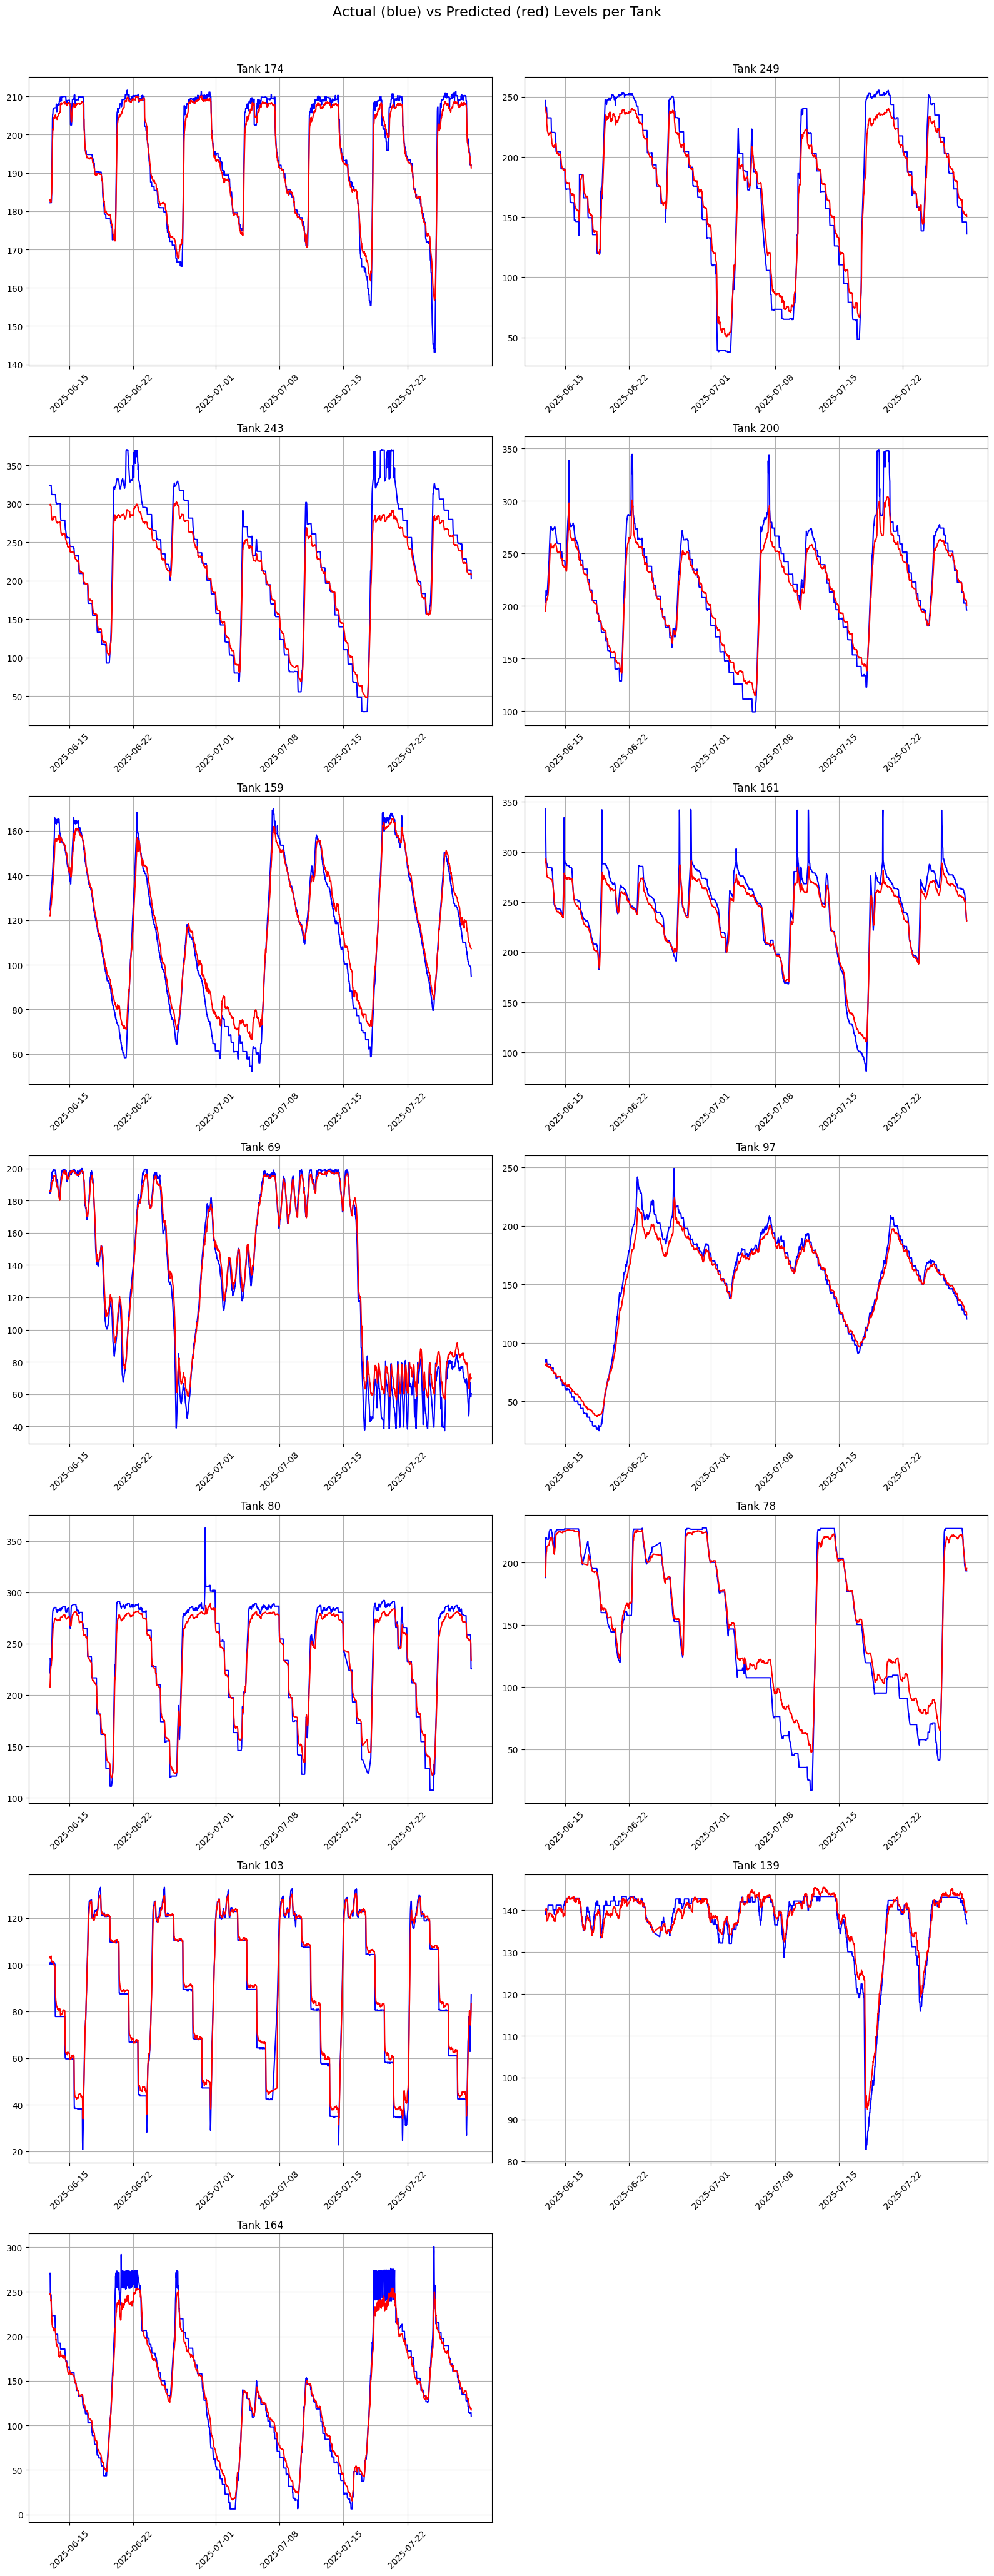

In [67]:
import matplotlib.pyplot as plt

# Get unique tanks
tank_ids = df_real_predic["tank_id"].unique()
n_tanks = len(tank_ids)

# Set grid size (e.g., 3 columns)
ncols = 2
nrows = (n_tanks + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*6), sharex=False, sharey=False)
axes = axes.flatten()

for i, tank in enumerate(tank_ids):
    ax = axes[i]
    df_plot = df_real_predic[df_real_predic["tank_id"] == tank]

    ax.plot(df_plot["updated_at"], df_plot["median_level"], label="Actual", color="blue")
    ax.plot(df_plot["updated_at"], df_plot["predicted_median_level"], label="Predicted", color="red")

    ax.set_title(f"Tank {tank}")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)

# Remove empty subplots if tanks < grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Actual (blue) vs Predicted (red) Levels per Tank", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

        

### Summary of Findings

The time-aware Extra Trees model confirmed the strong predictive signal identified in Phase 1, now validated on a chronological holdout (80 % train / 20 % test).

The experiment proved that weather features (temperature, precipitation, humidity—both tank & dam) have no predictive contribution and can be safely dropped.

The variable slope_30 was removed for leaking target information.

Adding lag, rolling, and seasonal features allowed the model to capture refill and consumption cycles, increasing temporal stability and interpretability.

On the 20 % future window, the model achieved R² ≈ 0.97, MAE ≈ 4.7, and sMAPE ≈ 5 %, showing accurate short-term forecasts across all tanks.

Visual inspection (actual vs predicted plots) confirmed consistent alignment between real and forecasted levels, with minor deviations during abrupt inflow events.

### Conclusions and Next Steps

This second phase established a production-ready forecasting pipeline using time-aware tree models and validated the decision to exclude non-informative weather variables.
Although the Extra Trees approach is robust, its computational cost is high; the next logical step is to evaluate LightGBM, which offers similar accuracy with greater efficiency and scalability for daily retraining.

Next phase objectives:

Replace Extra Trees with LightGBM and tune hyperparameters for speed and generalization.

Extend per-tank automation and integrate real-time prediction export to the SQL control layer.

Compare LightGBM results with the current model to quantify efficiency gains.